# 01 — Carga de Datos
## Pipeline CAD-TBX11K | Diagnóstico Asistido por Computador en Tuberculosis

Este notebook corresponde a la primera etapa del pipeline. Su propósito es configurar el entorno,
descargar el dataset **TBX11K** desde Kaggle y construir el **DataFrame base** que será utilizado
por todos los notebooks siguientes.

### Objetivo
Construir un DataFrame con la siguiente estructura:

| Columna       | Descripción                                      |
|---------------|--------------------------------------------------|
| `image_path`  | Ruta absoluta al archivo de imagen               |
| `class_name`  | Nombre de la clase: `health`, `sick` o `tb`      |
| `label`       | Etiqueta numérica: 0, 1 o 2                      |
| `ancho`       | Ancho original de la imagen en píxeles           |
| `alto`        | Alto original de la imagen en píxeles            |
| `modo`        | Modo de color PIL (p. ej. `RGB`, `L`)            |

### Clases del dataset

| Clase    | Etiqueta | Descripción                                         |
|----------|:--------:|-----------------------------------------------------|
| `health` |    0     | Radiografía de persona sana                         |
| `sick`   |    1     | Persona enferma, pero no diagnosticada con TB       |
| `tb`     |    2     | Tuberculosis confirmada                             |

### Referencias
- Dataset TBX11K: https://mmcheng.net/tb/
- kagglehub: https://github.com/Kaggle/kagglehub


## 0. Configuración del entorno

In [15]:
# Se agrega el directorio raíz del proyecto al path de Python para poder importar
# el módulo `src` desde cualquier ubicación de ejecución del notebook.
# Referencia: https://docs.python.org/3/library/sys.html#sys.path

import sys, os, warnings
import pandas as pd
import importlib

warnings.filterwarnings('ignore')
...

# La carpeta raíz del proyecto se ubica dos niveles por encima de `notebooks/`
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Raíz del proyecto: {PROJECT_ROOT}')

Raíz del proyecto: c:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K


In [16]:
# Se importan las funciones del módulo `cad_tbx11k.data` que encapsulan
# toda la lógica de carga y construcción del DataFrame base.
# Cada función está documentada en cad_tbx11k/data.py.

import warnings
warnings.filterwarnings('ignore')

from src.data import (
    setup_kaggle_credentials,   # Configura kaggle.json en ~/.kaggle/
    download_dataset,           # Descarga el dataset TBX11K via kagglehub
    get_data_root,              # Verifica y retorna la ruta TBX11K/
    map_dataset_structure,      # Mapea la estructura completa de imgs/
    build_base_dataframe,       # Construye el DataFrame base etiquetado
    LABEL_MAP, PALETTE,
)
from src.visualization import (
    set_publication_style,
    plot_dataset_distribution,
    plot_image_metadata,
)

## 1. Configuración de credenciales Kaggle

In [17]:
# Se configuran las credenciales de Kaggle copiando kaggle.json a ~/.kaggle/.
# Si el archivo ya existe en el destino, la copia se omite automáticamente.
# Para obtener el archivo: kaggle.com → Settings → API → Create New Token
# Documentación: https://www.kaggle.com/docs/api

# setup_kaggle_credentials()

## 2. Descarga del dataset

In [18]:
# Opción 1:
# Se descarga el dataset TBX11K mediante kagglehub.
# Si el dataset ya está en caché local, la descarga se omite.
# La variable `download_path` apunta al directorio raíz de la descarga.
# Referencia: https://github.com/Kaggle/kagglehub
# download_path = download_dataset()
# DATA_ROOT     = get_data_root(download_path)


# Opción 2:
# Descargado manualmente en carpeta data
DATA_ROOT = r"C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\TBX11K"

print(f"DATA_ROOT : {DATA_ROOT}")
print(f"Existe    : {os.path.exists(DATA_ROOT)}")


DATA_ROOT : C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\TBX11K
Existe    : True


## 3. Estructura completa del dataset

In [19]:
# Se mapea la estructura del directorio `imgs/` sin cargar ninguna imagen.
# Esto permite entender qué particiones contiene el dataset antes de filtrar.
# Se trabaja solo con health, sick y tb (subconjunto etiquetado).

resumen_df = map_dataset_structure(DATA_ROOT)
print(resumen_df.to_string(index=False))
print(f'\nTotal de imágenes en el dataset descargado: {resumen_df["imagenes"].sum()}')

carpeta  subcarpeta  imagenes
  extra       da+db         0
  extra mc+shenzhen         0
 health           -      3800
   sick           -      3800
     tb           -       800
   test           -      3302

Total de imágenes en el dataset descargado: 11702


## 4. Construcción del DataFrame base

In [20]:
# Se cargan únicamente las imágenes etiquetadas (health, sick, tb).
# Para cada imagen se registran ruta, clase, etiqueta y dimensiones originales.
# Las imágenes corruptas o ilegibles se omiten con una advertencia.
# Referencia PIL: https://pillow.readthedocs.io/en/stable/reference/Image.html

df_base = build_base_dataframe(DATA_ROOT)

# Limitar a pocas imágenes por clase para validar el pipeline
# Cambiar N_MUESTRA a None cuando se quiera usar el dataset completo
N_MUESTRA = 10

if N_MUESTRA:
    df_base = pd.concat([
        df_base[df_base['class_name'] == clase].sample(
            min(N_MUESTRA, len(df_base[df_base['class_name'] == clase])),
            random_state=42
        )
        for clase in LABEL_MAP
    ]).reset_index(drop=True)
    print(f'Modo prueba: {len(df_base)} imágenes ({N_MUESTRA} por clase)')
else:
    print(f'Dataset completo: {len(df_base)} imágenes')

print()
print(df_base['class_name'].value_counts())
print()
print(df_base.head())

Dataset cargado: 8400 imágenes en 3 clases (0 omitidas por error).
class_name
health    3800
sick      3800
tb         800
Modo prueba: 30 imágenes (10 por clase)

class_name
health    10
sick      10
tb        10
Name: count, dtype: int64

                                          image_path class_name  label  ancho  \
0  C:\Users\bernarda.salazar\Documents\GitHub\CAD...     health      0    512   
1  C:\Users\bernarda.salazar\Documents\GitHub\CAD...     health      0    512   
2  C:\Users\bernarda.salazar\Documents\GitHub\CAD...     health      0    512   
3  C:\Users\bernarda.salazar\Documents\GitHub\CAD...     health      0    512   
4  C:\Users\bernarda.salazar\Documents\GitHub\CAD...     health      0    512   

   alto modo  
0   512  RGB  
1   512  RGB  
2   512  RGB  
3   512  RGB  
4   512  RGB  


## 5. Visualización de la distribución del dataset

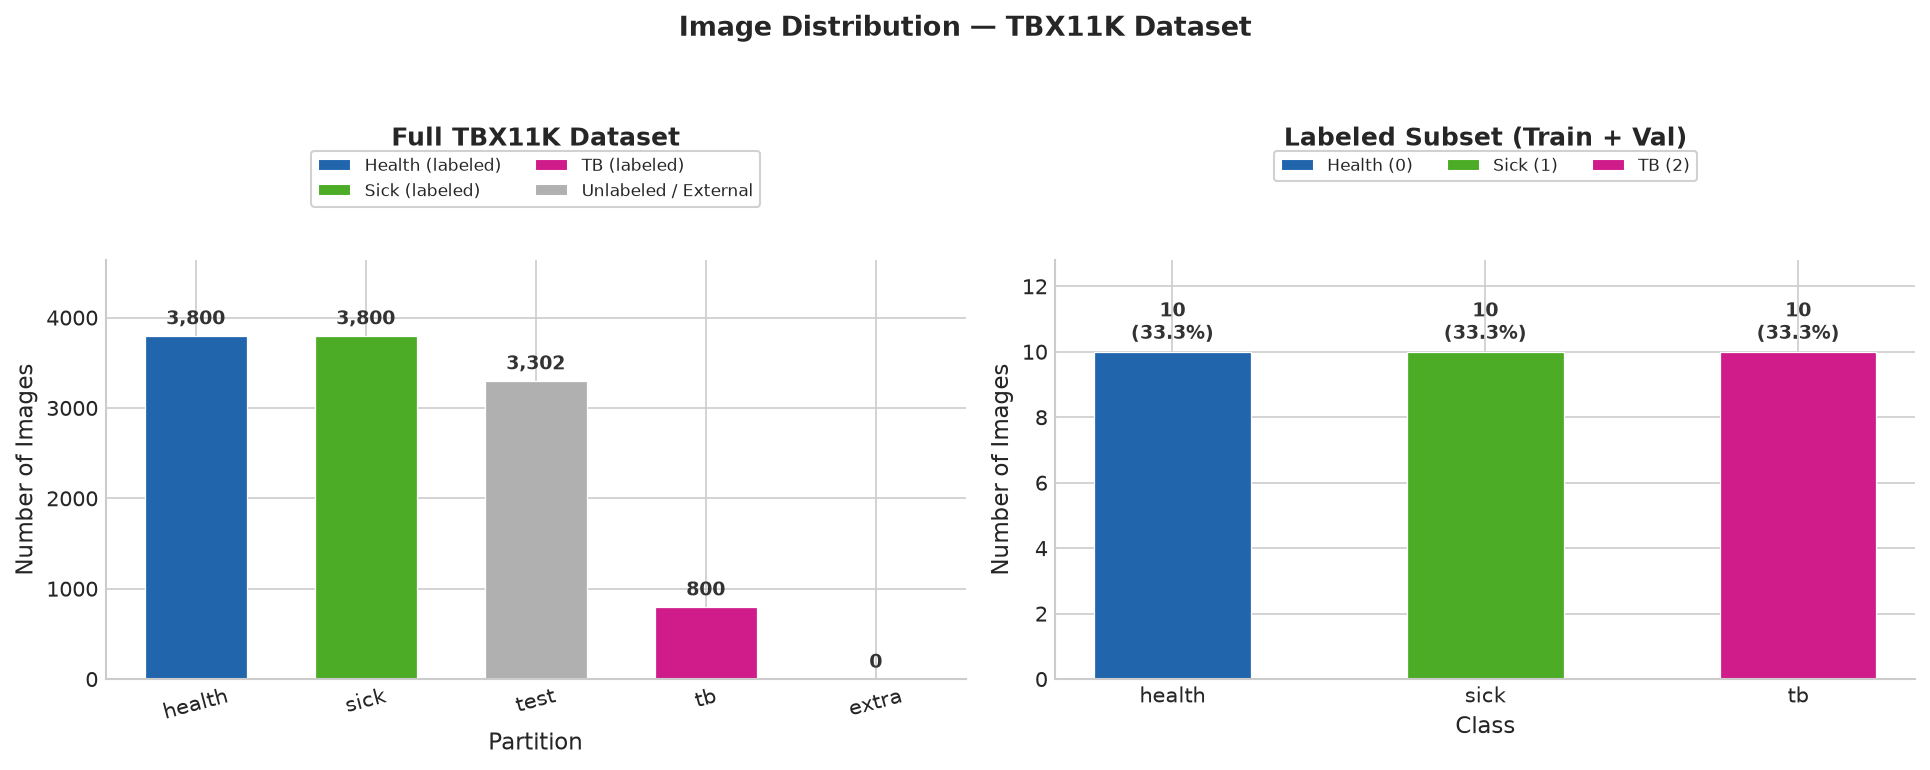

In [21]:
# Se genera el panel de distribución del dataset completo y del subconjunto
# etiquetado. Los porcentajes sobre las barras permiten verificar el desbalance
# de clases que deberá tenerse en cuenta en la etapa de modelado.
# Para guardar la figura, descomentar la línea correspondiente dentro de la función.

# set_publication_style()
# plot_dataset_distribution(resumen_df, df_base)

set_publication_style()
plot_dataset_distribution(resumen_df, df_base)

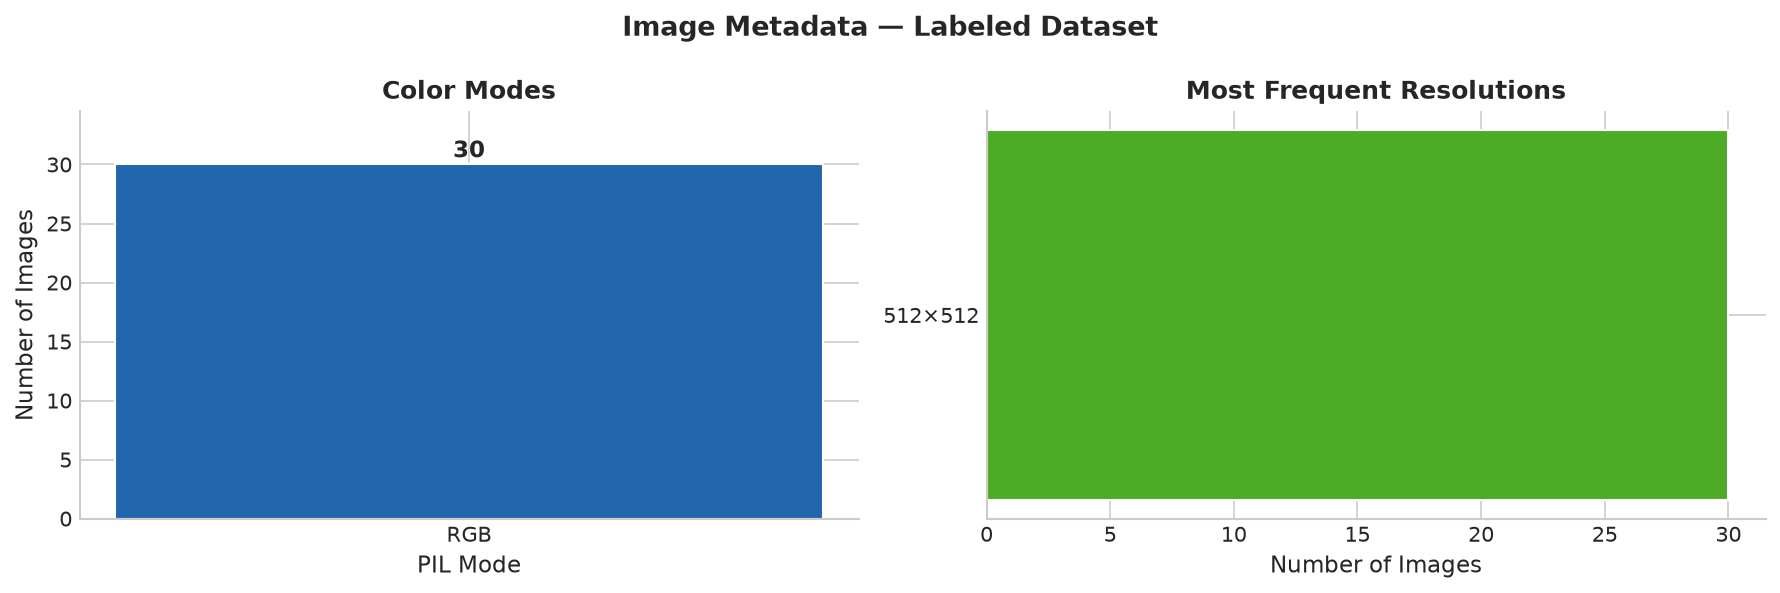

In [22]:
# Se visualizan los modos de color y las resoluciones más frecuentes en el dataset.
# La mayoría de las imágenes TBX11K son RGB; se convierten a escala de grises
# durante el preprocesamiento (notebook 03).
# Resoluciones heterogéneas justifican el resize a 256×256 del pipeline.

plot_image_metadata(df_base)

## 6. Resumen del DataFrame base

In [23]:
# Se imprime un resumen estadístico de las dimensiones originales de las imágenes.
# La variabilidad en ancho y alto confirma la necesidad de normalizar el tamaño.

from IPython.display import display, Markdown

# Resumen exploratorio del conjunto de imágenes

display(Markdown("### Distribución por clase"))
display(
    df_base['class_name']
    .value_counts()
    .rename_axis('Clase')
    .reset_index(name='Cantidad')
)

display(Markdown("### Estadísticas de dimensiones (px)"))
display(
    df_base[['ancho', 'alto']]
    .describe()
    .round(1)
)


### Distribución por clase

,Clase,Cantidad
0,health,10
1,sick,10
2,tb,10


### Estadísticas de dimensiones (px)

,ancho,alto
count,30.0,30.0
mean,512.0,512.0
std,0.0,0.0
min,512.0,512.0
25%,512.0,512.0
50%,512.0,512.0
75%,512.0,512.0
max,512.0,512.0


## Salida de este notebook

El DataFrame `df_base` queda disponible en memoria para ser utilizado directamente
en los notebooks siguientes ejecutados en la misma sesión, o bien puede exportarse:

```python
df_base.to_csv('../df_base.csv', index=False)
```

**Siguiente etapa:** `02_Analisis_Exploratorio.ipynb`


In [25]:
df_base.to_csv('../data/df_base.csv', index=False)